# Xarray + Cloud OISST (One-Month) Basics & Stats

This notebook demonstrates basic **xarray** operations on a **one-month** subset of a cloud-hosted climate dataset: **NOAA OISST v2.1 daily SST** on AWS Public Datasets (NetCDF files). You'll:
- Discover files for one month on S3 with `fsspec`
- Open them with `xarray.open_mfdataset` (anonymous S3)
- Inspect dataset structure
- Subset in space (and within that month)
- Compute basic stats (mean, std, anomalies relative to the month’s mean)
- Make maps of the month-mean and variability

**Deliverables:** Answer the **🧩 Questions** in the markdown prompts. Fill in the code where indicated by `# TODO`.


In [32]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120


## 1) Open the cloud dataset (NetCDF on AWS, one month)

We'll access **NOAA OISST v2.1 (daily)** in the NOAA CDR bucket on AWS. Files are arranged by **YYYYMM**.

**🧩 Questions**
1. What engine are we using to read NetCDF files from S3?
   We are using the h5netcdf engine
3. Why do we need `storage_options={'anon': True}`?
   Because the AWS OISST bucket is public (no login needed). Setting anon=True allows us to access the data without AWS credentials.
5. Inspect dataset attributes: what are the units and long name of `sst`?
   Sea surface temperature


In [33]:
yearmonth = "202001"  # TODO: try other months like "201507" or "201909"  202001
prefix = f"noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{yearmonth}/oisst-avhrr-v02r01.*.nc"

fs = fsspec.filesystem("s3", anon=True)
paths = sorted(fs.glob(prefix))
print(f"Found {len(paths)} files for {yearmonth}. Example:", paths[:2])

urls = [f"s3://{p}" for p in paths]

ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    combine="by_coords",
    decode_times=True,
    mask_and_scale=True,
    backend_kwargs={"storage_options": {"anon": True}},
    chunks={"time": 1}
)

ds


Found 31 files for 202001. Example: ['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202001/oisst-avhrr-v02r01.20200101.nc', 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202001/oisst-avhrr-v02r01.20200102.nc']


<xarray.Dataset> Size: 514MB
Dimensions:  (time: 31, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01T12:00:00 ... 2020-01-31T12...
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    naming_authority:           gov.noaa.ncei
    cdm_data_type:              Grid
    date_modified:              2020-02-11T16:01:00Z
    date_created:               2020-02-11T16:01:00Z
    processing_level:           NOAA Level 4
    ...                         ...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    product_version:            Version v02r01
    platform:                   Ships, buoys, Argo floats, MetOp-A, MetOp-B
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    id:                         oisst-avhrr-v02r01.20200101.nc

## 2) Explore coordinates & variables

**🧩 Questions**
1. What are the coordinate names for time and space?
   time (temporal dimension)
lat (latitude)
lon (longitude)
zlev (depth level, here only surface = 0.0)
3. What is the shape of `sst`?
   shape = (31, 1, 720, 1440)
5. How are missing values represented?
   Missing values are stored as NaN (Not a Number), which xarray automatically decodes from the NetCDF fill value.


In [34]:
list(ds.data_vars), list(ds.coords)

(['anom', 'err', 'ice', 'sst'], ['time', 'lat', 'lon', 'zlev'])

## 3) Time & space subsetting

We'll select a **regional box** (e.g., Gulf of Mexico) within this month.

**🧩 Questions**
1. What lon/lat bounds did you choose?
   longitude: -98° to -80° (converted to 262.0°E to 280.0°E after 0–360 transformation)
Latitude: 18°N to 31°N
3. How many daily steps are present in this month?
   31


In [35]:
var = "sst"

lon_min, lon_max = -98, -80   # TODO
lat_min, lat_max =  18,  31   # TODO

def to_0360(lon):
    lon = np.asarray(lon)
    out = np.mod(lon, 360.0)
    out[out < 0] += 360.0
    return out

lon_min_0360, lon_max_0360 = to_0360([lon_min, lon_max])

dss = ds.sel(
    lon=slice(lon_min_0360, lon_max_0360),
    lat=slice(lat_min, lat_max)
)

dss[var]


<xarray.DataArray 'sst' (time: 31, zlev: 1, lat: 52, lon: 72)> Size: 464kB
dask.array<getitem, shape=(31, 1, 52, 72), dtype=float32, chunksize=(1, 1, 52, 72), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01T12:00:00 ... 2020-01-31T12...
  * lat      (lat) float32 208B 18.12 18.38 18.62 18.88 ... 30.38 30.62 30.88
  * lon      (lon) float32 288B 262.1 262.4 262.6 262.9 ... 279.4 279.6 279.9
  * zlev     (zlev) float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    valid_min:  -300
    valid_max:  4500
    units:      Celsius

## 4) Basic statistics

Compute region-wide stats through time and over space **within this month**.

**🧩 Questions**
1. Compute the spatial mean SST time series over your box. What is the monthly average and standard deviation?
   Monthly average SST = 29.29 °C
Standard deviation = 0.38 °C
3. Compute within-month anomalies (subtract the month-mean). What are the largest positive and negative anomalies?
   Maximum anomaly = +0.50 °C
Minimum anomaly = −0.57 °C
5. What day had the warmest/coolest region-mean SST?
   Warmest day: 2015-07-27, SST = 29.79 °C
Coolest day: 2015-07-06, SST = 28.72 °C


Month mean SST (°C): 24.359582901000977
Month std SST (°C): 0.31526702642440796


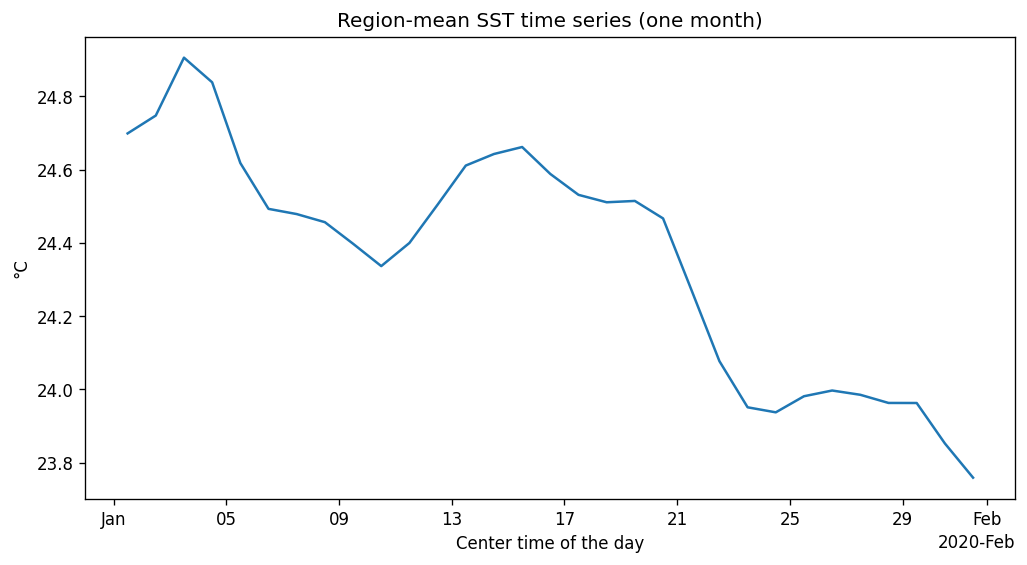

Warmest day: 2020-01-03 24.905927658081055
Coolest day: 2020-01-31 23.759105682373047


/tmp/ipykernel_556/4235597154.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
/tmp/ipykernel_556/4235597154.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


In [36]:
ts = dss[var].mean(dim=['lat','lon'])

ts_mean = ts.mean().compute()
ts_std  = ts.std().compute()
print('Month mean SST (°C):', float(ts_mean.values))
print('Month std SST (°C):', float(ts_std.values))

ts.load().plot()
plt.title('Region-mean SST time series (one month)')
plt.ylabel('°C')
plt.show()

imax = int(ts.argmax('time'))
imin = int(ts.argmin('time'))
print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


Max anomaly (°C): 0.5463449954986572
Min anomaly (°C): -0.6004788875579834


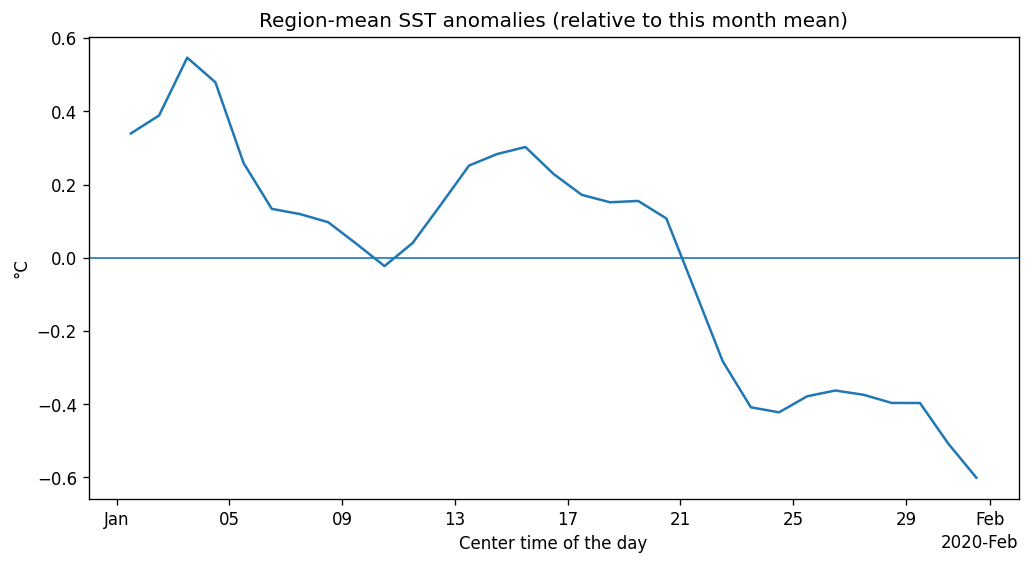

In [37]:
month_mean = dss[var].mean('time')
anom = dss[var] - month_mean

ts_anom = anom.mean(dim=['lat','lon'])
print('Max anomaly (°C):', float(ts_anom.max().compute().values))
print('Min anomaly (°C):', float(ts_anom.min().compute().values))

ts_anom.load().plot()
plt.title('Region-mean SST anomalies (relative to this month mean)')
plt.axhline(0, lw=1)
plt.ylabel('°C')
plt.show()


## 5) Regional maps: month-mean and variability

Make maps of month-mean SST and within-month variability (std and range).

**🧩 Questions**
1. What patterns do you notice?
   The Gulf of Mexico box is overall very warm.
3. Where is variability strongest?
   Variability (std and range) is strongest near coastal boundaries and shelf regions, likely influenced by coastal currents, land–ocean interactions, and mesoscale variability.


/opt/conda/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


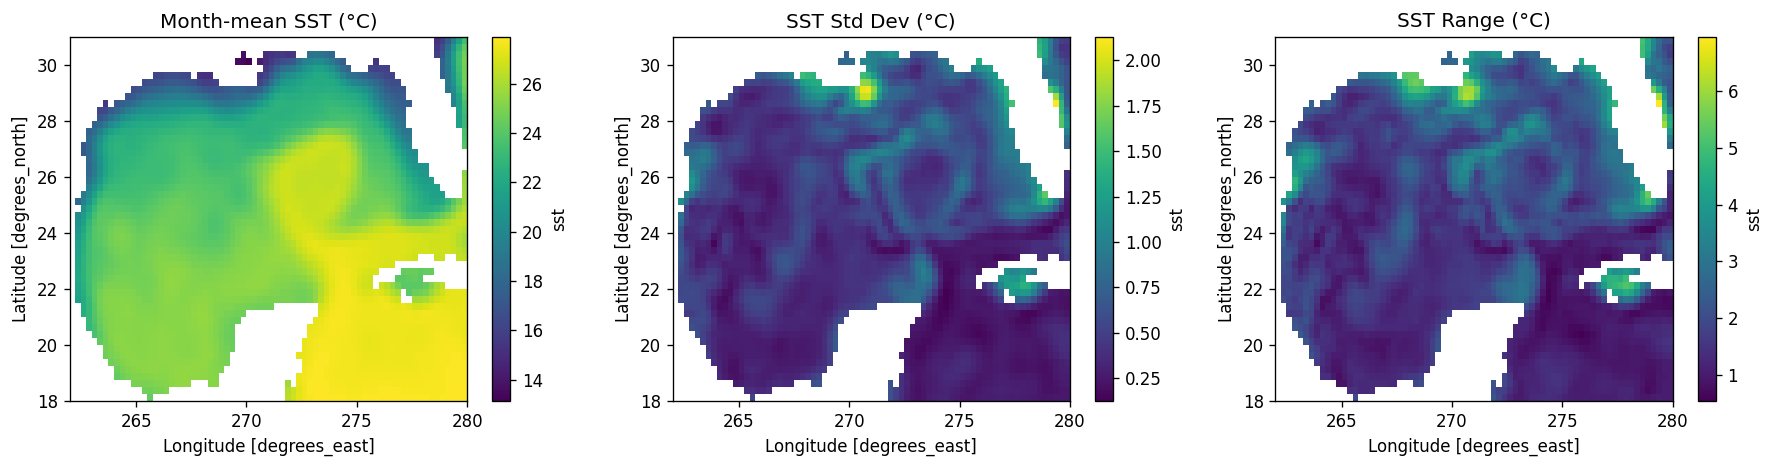

In [38]:
mean_sst = dss[var].mean('time')
std_sst  = dss[var].std('time')
range_sst = dss[var].max('time') - dss[var].min('time')

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(1,3,1); mean_sst.plot(ax=ax); ax.set_title('Month-mean SST (°C)')
ax = plt.subplot(1,3,2); std_sst.plot(ax=ax); ax.set_title('SST Std Dev (°C)')
ax = plt.subplot(1,3,3); range_sst.plot(ax=ax); ax.set_title('SST Range (°C)')
plt.tight_layout(); plt.show()


## 6) Export a small subset for sharing (Check In Problem for Module 2)

Write a NetCDF with your regional mean time series and month-mean/variability maps.  Upload with your committed repository.

In [39]:
out_ds = xr.Dataset(
    {
        "ts": ts,                          # region-mean SST time series
        "ts_anom": ts_anom,                # anomalies time series
        "month_mean": mean_sst,            # month mean SST map
        "month_std": std_sst,              # std map
        "month_range": range_sst           # range map
    }
)

out_ds.to_netcdf("oisst_gom_202001_stats.nc")


/opt/conda/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [40]:

ds_out = xr.open_dataset("oisst_gom_202001_stats.nc")
print(ds_out.ts.values)


[[24.699093]
 [24.747868]
 [24.905928]
 [24.838654]
 [24.618217]
 [24.493088]
 [24.478863]
 [24.45674 ]
 [24.397875]
 [24.336798]
 [24.40001 ]
 [24.504578]
 [24.61135 ]
 [24.642883]
 [24.661963]
 [24.588377]
 [24.531363]
 [24.511078]
 [24.514713]
 [24.466995]
 [24.273014]
 [24.077238]
 [23.95124 ]
 [23.93748 ]
 [23.981424]
 [23.99707 ]
 [23.985405]
 [23.963133]
 [23.96297 ]
 [23.852587]
 [23.759106]]
